In [ ]:
%%capture
!pip install lightning adversarial-robustness-toolbox[pytorch_image] umap-learn tsnecuda==3.0.1+cu122 -f https://tsnecuda.isx.ai/tsnecuda_stable.html

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals, annotations
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Callable, TYPE_CHECKING

import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import *
import umap

from tqdm.auto import tqdm

from einops import rearrange
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
import torchvision.models as models
import torchmetrics

import art
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier
from art.config import ART_NUMPY_DTYPE
from art.defences.preprocessor import *
from art.defences.preprocessor.preprocessor import Preprocessor

if TYPE_CHECKING:
    from art.utils import CLIP_VALUES_TYPE

from lightning import LightningModule

2025-06-07 22:59:17.413741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749337157.441990   11701 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749337157.450427   11701 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
%env OMP_NUM_THREADS=1

env: OMP_NUM_THREADS=1


In [3]:
class PCAMDataset(Dataset):
    """Optimized PCAM Dataset with lazy loading"""
    
    def __init__(self, input_file_path: str, label_file_path: str, 
                 transform=None, max_samples: Optional[int] = None):
        self.input_file_path = input_file_path
        self.label_file_path = label_file_path
        self.transform = transform
        self.max_samples = max_samples
        
        # Open files and keep references
        self.input_file = h5py.File(self.input_file_path, 'r')
        self.label_file = h5py.File(self.label_file_path, 'r')
        
        self.input_data = self.input_file["x"]
        self.label_data = self.label_file["y"]
        
        # Set length
        self.length = len(self.input_data)
        if max_samples is not None:
            self.length = min(max_samples, self.length)
            print(f"Using {max_samples}/{len(self.input_data)} samples")
            
    def __len__(self) -> int:
        return self.length
    
    def __getitem__(self, idx: int):
        if idx >= self.length:
            raise IndexError("Index out of range")
        
        # Load image and convert to PIL
        image = Image.fromarray(self.input_data[idx]).convert("RGB")
        label = int(self.label_data[idx, 0, 0, 0])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
    
    def __del__(self):
        # Close files when dataset is destroyed
        if hasattr(self, 'input_file'):
            self.input_file.close()
        if hasattr(self, 'label_file'):
            self.label_file.close()

In [4]:
class ResNet18Classifier(LightningModule):
    def __init__(self, num_classes: int = 2, label_smoothing: float = 0.0):
        super().__init__()
        self.model = models.resnet18(weights='DEFAULT')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.num_classes = num_classes
        
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

        self.train_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.train_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.val_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.test_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, stage: str):
        images, labels = batch

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)

        if stage == "train":
            self.train_acc(preds, labels)
            self.train_auroc(probs, labels)
        elif stage == "val":
            self.val_acc(preds, labels)
            self.val_auroc(probs, labels)
        elif stage == "test":
            self.test_acc(preds, labels)
            self.test_auroc(probs, labels)
        else:
            raise ValueError(f"Unknown stage: {stage}")
        
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)        
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")
    def validation_step(self, batch, batch_idx):
        return self._step(batch, "val")
    def test_step(self, batch, batch_idx):
        return self._step(batch, "test")

    def on_train_epoch_end(self):
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_auroc", self.train_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.train_acc.reset()
        self.train_auroc.reset()
    
    def on_validation_epoch_end(self):
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_auroc", self.val_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.val_acc.reset()
        self.val_auroc.reset()

    def on_test_epoch_end(self):
        self.log("test_acc", self.test_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_auroc", self.test_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.test_acc.reset()
        self.test_auroc.reset()

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=1e-3, weight_decay=0.05)
        
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.1, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }
        
    def freeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = False
        for param in self.model.fc.parameters():  # Keep classifier trainable
            param.requires_grad = True

    def unfreeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = True

In [5]:
# Configuration
DATA_ROOT = "/kaggle/input/metastatic-tissue-classification-patchcamelyon"
MODEL_PATH = "/kaggle/input/hermes_resnet_18/pytorch/lightning/1/reduced_dataset_10ep.ckpt"
BATCH_SIZE = 512
OUTPUT_DIR = Path("comprehensive_evaluation_results")
OUTPUT_DIR.mkdir(exist_ok=True)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [6]:
# Data transforms
eval_transform = transforms.Compose([
    transforms.ToTensor(), # here they become [0, 1] due to torch backend with Pillow
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [7]:
# Load dataset
print("Loading test dataset...")
test_dataset = PCAMDataset(
    input_file_path=os.path.join(DATA_ROOT, "pcam/test_split.h5"),
    label_file_path=os.path.join(DATA_ROOT, "Labels/Labels/camelyonpatch_level_2_split_test_y.h5"),
    transform=eval_transform,
    max_samples=5000  # Reduced for faster evaluation
)

Loading test dataset...
Using 5000/32768 samples


In [8]:
# Load model
print("Loading model...")
model = ResNet18Classifier.load_from_checkpoint(MODEL_PATH)

Loading model...


In [9]:
class GaussianSmoothing(Preprocessor):
    params = ["sigma", "verbose"]

    def __init__(
        self,
        clip_values: "CLIP_VALUES_TYPE" | None = None,
        sigma: float = 1.0,
        apply_fit: bool = True,
        apply_predict: bool = True,
        verbose: bool = False,
    ):
        """
        Some description of the class
        """
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.sigma = sigma
        self.clip_values = clip_values
        self.verbose = verbose
        self._check_params()

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:

        x_aug = np.random.normal(x, scale=self.sigma, size=x.shape).astype(ART_NUMPY_DTYPE)
        y_aug = y
        
        if self.clip_values is not None:
            x_aug = np.clip(x_aug, self.clip_values[0], self.clip_values[1])

        return x_aug, y_aug
        

    def _check_params(self) -> None:
        if not isinstance(self.sigma, float) or self.sigma <= 0:
            raise ValueError("Smoothing sigma must be a positive float.")

        if self.clip_values is not None:

            if len(self.clip_values) != 2:
                raise ValueError(
                    "`clip_values` should be a tuple of 2 floats or arrays containing the allowed data range."
                )
            if np.array(self.clip_values[0] >= self.clip_values[1]).any():
                raise ValueError("Invalid `clip_values`: min >= max.")

In [ ]:
class UnNormalize(torch.nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = torch.tensor(mean).view(3,1,1)
        self.std  = torch.tensor(std ).view(3,1,1)
    
    def forward(self, tensor):
        # tensor is C×H×W, normalized
        return tensor * self.std + self.mean

class Rescale01(torch.nn.Module):
    """Rescale C×H×W tensor so its min→0 and max→1."""
    def forward(self, t):
        tmin, tmax = float(t.min()), float(t.max())
        if tmax <= tmin:
            return torch.zeros_like(t)
        return (t - tmin) / (tmax - tmin)

class TransformedDataset(Dataset):
    """Small wrapper to apply transform and do unnorm + 0-1 minmax scaling"""
    def __init__(self, base_dataset: Dataset, transform: Callable):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]           # x: torch.Tensor C×H×W
        x_t = self.transform(x)
        return x_t, y

class MyFramework:
    """
    Modular framework for evaluating ART attacks and defenses.
    """
    def __init__(
        self,
        model: torch.nn.Module,
        test_dataset: torch.utils.data.Dataset,
        loss: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        channels_first: bool,
        class_names: Optional[List[str]] = None,
        clip_values: Optional[Tuple[int, int]] = None,
        batch_size: int = 64
    ):
        # Core attributes
        self.model = model
        self.test_dataset = test_dataset
        self.loss = loss
        self.optimizer = optimizer
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.channels_first = channels_first
        self.clip_values = clip_values
        self.batch_size = batch_size
        self.class_names = class_names or [f"Class_{i}" for i in range(num_classes)]

        # Instantiate base classifier without defenses
        self.base_classifier = self._build_classifier(defences=None)

        # Registries for attacks and defenses
        self.attacks: List[Tuple[str, Callable[[art.attacks], Any]]] = []
        self.defenses: List[Tuple[str, Callable[[art.defences.preprocessor.preprocessor], Any]]] = []

        # Storage for detailed analysis
        self.detailed_results = {}
        self.adversarial_datasets = {}
        self.prediction_data = {}

    def _build_classifier(self, defences: Optional[List[Any]] = None):
        """Return a new PyTorchClassifier with optional preprocessing defenses."""
        from art.estimators.classification import PyTorchClassifier
        return PyTorchClassifier(
            model=self.model,
            loss=self.loss,
            optimizer=self.optimizer,
            input_shape=self.input_shape,
            nb_classes=self.num_classes,
            channels_first=self.channels_first,
            clip_values=self.clip_values,
            preprocessing_defences=defences
        )

    def _make_dataloader(self, dataset: torch.utils.data.Dataset) -> DataLoader:
        """Create a DataLoader for the given dataset."""
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            pin_memory=True
        )

    def _generate_adversarial_dataset(
        self,
        classifier: PyTorchClassifier,
        attack_fn: Callable[[PyTorchClassifier], Any],
        attack_name: str
    ) -> Tuple[Dataset, Dict]:
        """Generate adversarial examples and collect detailed metrics."""
        attack = attack_fn(classifier)
        loader = self._make_dataloader(self.test_dataset)

        adv_images, adv_labels = [], []
        original_images, perturbations = [], []
        original_preds, adv_preds = [], []
        original_confs, adv_confs = [], []

        for X, y in tqdm(loader, desc=f"Crafting adversarial ({attack.__class__.__name__})"):
            # Generate adversarial examples
            x_adv = attack.generate(x=X.numpy())
            
            # Get predictions and confidences
            orig_pred_probs = classifier.predict(X.numpy())
            adv_pred_probs = classifier.predict(x_adv)
            
            # Store data
            adv_images.append(x_adv)
            adv_labels.append(y)
            original_images.append(X.numpy())
            perturbations.append(x_adv - X.numpy())
            
            original_preds.append(orig_pred_probs.argmax(axis=1))
            adv_preds.append(adv_pred_probs.argmax(axis=1))
            original_confs.append(orig_pred_probs.max(axis=1))
            adv_confs.append(adv_pred_probs.max(axis=1))

        # Concatenate all data
        X_adv = np.concatenate(adv_images, axis=0)
        y_adv = torch.cat(adv_labels)
        X_orig = np.concatenate(original_images, axis=0)
        perturbations_all = np.concatenate(perturbations, axis=0)
        
        # Create detailed results dictionary
        details = {
            'original_images': X_orig,
            'adversarial_images': X_adv,
            'perturbations': perturbations_all,
            'original_predictions': np.concatenate(original_preds),
            'adversarial_predictions': np.concatenate(adv_preds),
            'original_confidences': np.concatenate(original_confs),
            'adversarial_confidences': np.concatenate(adv_confs),
            'true_labels': y_adv.numpy()
        }
        
        self.detailed_results[attack_name] = details
        
        return TensorDataset(torch.from_numpy(X_adv), y_adv), details

    def _evaluate_dataset(
        self,
        dataset: torch.utils.data.Dataset,
        classifier: PyTorchClassifier,
        name: str
    ) -> Tuple[float, Dict]:
        """Compute accuracy and collect detailed prediction information."""
        loader = self._make_dataloader(dataset)
        all_preds, all_labels, all_confs = [], [], []
        
        for X, y in loader:
            pred_probs = classifier.predict(X.numpy())
            preds = pred_probs.argmax(axis=1)
            confs = pred_probs.max(axis=1)
            
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
            all_confs.extend(confs)
        
        accuracy = accuracy_score(all_labels, all_preds)
        
        details = {
            'predictions': np.array(all_preds),
            'true_labels': np.array(all_labels),
            'confidences': np.array(all_confs)
        }
        
        return accuracy, details

    def add_attack(
        self,
        name: str,
        attack_fn: Callable[[PyTorchClassifier], Any]
    ):
        """Register an attack factory."""
        self.attacks.append((name, attack_fn))

    def add_defense(
        self,
        name: str,
        defense_fn: Callable[[], Any]
    ):
        """Register a defense factory."""
        self.defenses.append((name, defense_fn))

    def run_experiments(self, output_file: str) -> pd.DataFrame:
        """Run all combinations of clean, attacks, and defenses, return results DataFrame."""

        output_path = Path(output_file)
        if output_path.suffix != '.csv':
            raise ValueError("Output file must be a CSV file.")

        results = []

        # Clean data
        clean_acc, clean_details = self._evaluate_dataset(self.test_dataset, self.base_classifier, name="clean")
        results.append({"attack": "none", "defense": "none", "accuracy": clean_acc})

        # Loop over attacks
        for atk_name, atk_fn in self.attacks:
            print(f"\nProcessing attack: {atk_name}")
            # Generate adversarial set
            if not self.adversarial_datasets.get(atk_name):
                adv_ds, attack_details = self._generate_adversarial_dataset(self.base_classifier, atk_fn, atk_name)
                self.adversarial_datasets[atk_name] = adv_ds
            else:
                adv_ds = self.adversarial_datasets[atk_name]

            # Evaluate adv without defense
            atk_acc, _ = self._evaluate_dataset(adv_ds, self.base_classifier, name=f"{atk_name}_no_defense")
            results.append({"attack": atk_name, "defense": "none", "accuracy": atk_acc})

            # Evaluate adv with each defense
            # some specific defenses require attention in their expected input
            for def_name, def_fn in self.defenses:
                clf_def = self._build_classifier(defences=[def_fn()])
                
                # if doing JPEG Compression, input X must be [0,1] range or [0,255]
                if 'jpeg' in def_name.lower():
                    unnorm = UnNormalize(IMAGENET_MEAN, IMAGENET_STD) # unnormalize class

                    # compose the transforms needed
                    jpeg_preproc = transforms.Compose([
                        unnorm, # undo mean/std
                        Rescale01(), # back to [0,1] since unnorm on adversarial leads to slightly lower than 0 and higher than 1 values
                    ])

                    # create a new dataset with that transform
                    jpeg_ds = TransformedDataset(adv_ds, jpeg_preproc) 
                    def_acc, _ = self._evaluate_dataset(jpeg_ds, clf_def, name=f"{atk_name}_{def_name}")

                elif 'mp3' in def_name.lower():
                    raise NotImplementedError("MP3 compression defense is not implemented yet. The main issue is that you need to convert the image tensor to downsampling the number of channels to 1 or 2 (mono/stereo) and then apply the MP3 compression by flattening H and W dimensions. But then you need to reshape it back to C×H×W, while having only 1 or 2 channels.")
                    
                # for other cases we just evaluate the defense on the adversarial examples
                else:  
                    def_acc, _ = self._evaluate_dataset(adv_ds, clf_def, name=f"{atk_name}_{def_name}")
                    
                results.append({"attack": atk_name, "defense": def_name, "accuracy": def_acc})

        # Save results to CSV
        results_df = pd.DataFrame(results)
        results_df.to_csv(str(output_path.absolute()), index=False, float_format='%.4f')
        return results_df

    #####################
    #        PLOT       #
    #####################
    def plot_example(self, example: torch.Tensor, original: Optional[torch.Tensor] = None, denormalize: bool = True):
        """Plot an example tensor, optionally denormalizing and showing original image."""

        if denormalize:
            # Denormalize the example tensor
            unnorm = UnNormalize(IMAGENET_MEAN, IMAGENET_STD)
            example = unnorm(example)
            
        # Rearrange and convert the example tensor to a NumPy array
        img = rearrange(example, 'C H W -> H W C').numpy().squeeze()
    
        if original is not None:
            # Rearrange and convert the original tensor to a NumPy array
            orig_img = rearrange(original, 'C H W -> H W C').numpy().squeeze()
    
            # Create a figure with two subplots side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
            # Display the original image
            axes[0].imshow(orig_img)
            axes[0].set_title('Original')
            axes[0].axis('off')
    
            # Display the processed image
            axes[1].imshow(img)
            axes[1].set_title('Processed')
            axes[1].axis('off')
    
            plt.tight_layout()
            plt.show()
        else:
            # Display only the processed image
            plt.imshow(img)
            plt.axis('off')
            plt.title('Processed')
            plt.show()

    def plot_accuracy_heatmap(self, results_df: pd.DataFrame):
        """Plot accuracy heatmap for attack-defense combinations."""
        pivot_table = results_df.pivot(index='attack', columns='defense', values='accuracy')
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=0.5, 
                   square=True, fmt='.3f', cbar_kws={'label': 'Accuracy'})
        plt.title('Attack vs Defense Effectiveness Heatmap')
        plt.ylabel('Attack Method')
        plt.xlabel('Defense Method')
        plt.tight_layout()
        plt.show()

    def plot_confidence_distributions(self, attack_name: str):
        """Plot confidence distributions before and after attack."""
        if attack_name not in self.detailed_results:
            print(f"No detailed results found for attack: {attack_name}")
            return
            
        details = self.detailed_results[attack_name]
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Original confidences
        axes[0].hist(details['original_confidences'], bins=50, alpha=0.7, 
                    color='blue', label='Original')
        axes[0].set_xlabel('Confidence')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Original Prediction Confidence\n(Mean: {details["original_confidences"].mean():.3f})')
        axes[0].grid(True, alpha=0.3)
        
        # Adversarial confidences
        axes[1].hist(details['adversarial_confidences'], bins=50, alpha=0.7, 
                    color='red', label='Adversarial')
        axes[1].set_xlabel('Confidence')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title(f'Adversarial Prediction Confidence\n(Mean: {details["adversarial_confidences"].mean():.3f})')
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle(f'Confidence Distribution Analysis - {attack_name}')
        plt.tight_layout()
        plt.show()

    def plot_perturbation_analysis(self, attack_name: str, num_samples: int = 9):
        """Visualize perturbations and their properties."""
        if attack_name not in self.detailed_results:
            print(f"No detailed results found for attack: {attack_name}")
            return
            
        details = self.detailed_results[attack_name]
        perturbations = details['perturbations']
        
        # Calculate perturbation norms
        l2_norms = np.linalg.norm(perturbations.reshape(len(perturbations), -1), axis=1)
        linf_norms = np.max(np.abs(perturbations.reshape(len(perturbations), -1)), axis=1)
        
        fig = plt.figure(figsize=(18, 12))
        
        # Perturbation examples
        for i in range(min(num_samples, len(perturbations))):
            # Original image
            ax1 = plt.subplot(4, num_samples, i + 1)
            orig_img = rearrange(details['original_images'][i], 'C H W -> H W C')
            plt.imshow(np.clip(orig_img, 0, 1))
            plt.title(f'Original {i+1}')
            plt.axis('off')
            
            # Adversarial image
            ax2 = plt.subplot(4, num_samples, i + 1 + num_samples)
            adv_img = rearrange(details['adversarial_images'][i], 'C H W -> H W C')
            plt.imshow(np.clip(adv_img, 0, 1))
            plt.title(f'Adversarial {i+1}')
            plt.axis('off')
            
            # Perturbation (amplified for visibility)
            ax3 = plt.subplot(4, num_samples, i + 1 + 2*num_samples)
            pert_img = rearrange(perturbations[i], 'C H W -> H W C')
            pert_img = (pert_img - pert_img.min()) / (pert_img.max() - pert_img.min())
            plt.imshow(pert_img)
            plt.title(f'Perturbation {i+1}\nL2: {l2_norms[i]:.3f}')
            plt.axis('off')
        
        # Perturbation norm distributions
        ax4 = plt.subplot(4, 3, 10)
        plt.hist(l2_norms, bins=50, alpha=0.7, color='blue')
        plt.xlabel('L2 Norm')
        plt.ylabel('Frequency')
        plt.title(f'L2 Perturbation Norms\n(Mean: {l2_norms.mean():.3f})')
        plt.grid(True, alpha=0.3)
        
        ax5 = plt.subplot(4, 3, 11)
        plt.hist(linf_norms, bins=50, alpha=0.7, color='green')
        plt.xlabel('L∞ Norm')
        plt.ylabel('Frequency')
        plt.title(f'L∞ Perturbation Norms\n(Mean: {linf_norms.mean():.3f})')
        plt.grid(True, alpha=0.3)
        
        # Perturbation correlation with success
        ax6 = plt.subplot(4, 3, 12)
        success = (details['original_predictions'] != details['adversarial_predictions']).astype(int)
        plt.scatter(l2_norms, success, alpha=0.5)
        plt.xlabel('L2 Perturbation Norm')
        plt.ylabel('Attack Success')
        plt.title('Perturbation Norm vs Success')
        plt.grid(True, alpha=0.3)
        
        plt.suptitle(f'Perturbation Analysis - {attack_name}', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_class_vulnerability_matrix(self, results_df: pd.DataFrame):
        """Plot vulnerability matrix showing which classes are most affected by each attack."""
        attack_names = [name for name in results_df['attack'].unique() if name != 'none']
        
        vulnerability_matrix = np.zeros((len(attack_names), self.num_classes))
        
        for i, attack_name in enumerate(attack_names):
            if attack_name in self.detailed_results:
                details = self.detailed_results[attack_name]
                for class_idx in range(self.num_classes):
                    class_mask = details['true_labels'] == class_idx
                    if class_mask.sum() > 0:
                        class_success = (details['original_predictions'][class_mask] != 
                                       details['adversarial_predictions'][class_mask])
                        vulnerability_matrix[i, class_idx] = class_success.mean()
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(vulnerability_matrix, 
                   xticklabels=self.class_names,
                   yticklabels=attack_names,
                   annot=True, fmt='.3f', cmap='Reds',
                   cbar_kws={'label': 'Attack Success Rate'})
        plt.title('Class Vulnerability Matrix')
        plt.xlabel('Class')
        plt.ylabel('Attack Method')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_feature_space_analysis(self, attack_name: str, method: str = 'tsne', n_samples: int = 1000):
        """Plot t-SNE or UMAP visualization of feature space."""
        if attack_name not in self.detailed_results:
            print(f"No detailed results found for attack: {attack_name}")
            return
            
        details = self.detailed_results[attack_name]
        
        # Sample data if too large
        if len(details['original_images']) > n_samples:
            indices = np.random.choice(len(details['original_images']), n_samples, replace=False)
            orig_data = details['original_images'][indices].reshape(n_samples, -1)
            adv_data = details['adversarial_images'][indices].reshape(n_samples, -1)
            labels = details['true_labels'][indices]
        else:
            orig_data = details['original_images'].reshape(len(details['original_images']), -1)
            adv_data = details['adversarial_images'].reshape(len(details['adversarial_images']), -1)
            labels = details['true_labels']
        
        # Combine original and adversarial data
        combined_data = np.vstack([orig_data, adv_data])
        combined_labels = np.hstack([labels, labels])
        data_type = np.hstack([np.zeros(len(labels)), np.ones(len(labels))])  # 0 for original, 1 for adversarial
        
        # Apply dimensionality reduction
        if method.lower() == 'tsne':
            #reducer = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=1)
            from tsnecuda import TSNE
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=10)
        else:
            reducer = umap.UMAP(n_components=2, random_state=42)
            
        embedded = reducer.fit_transform(combined_data)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Color by class
        scatter1 = axes[0].scatter(embedded[:, 0], embedded[:, 1], 
                                  c=combined_labels, cmap='tab10', 
                                  alpha=0.6, s=20)
        axes[0].set_title(f'{method.upper()} - Colored by Class')
        axes[0].grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=axes[0])
        
        # Color by data type (original vs adversarial)
        colors = ['blue', 'red']
        for i, data_t in enumerate(['Original', 'Adversarial']):
            mask = data_type == i
            axes[1].scatter(embedded[mask, 0], embedded[mask, 1], 
                          c=colors[i], label=data_t, alpha=0.6, s=20)
        
        axes[1].set_title(f'{method.upper()} - Original vs Adversarial')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle(f'Feature Space Analysis - {attack_name}', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_defense_robustness_curves(self, results_df: pd.DataFrame):
        """Plot enhanced robustness curves for different defenses across attacks."""
        attacks = [name for name in results_df['attack'].unique() if name != 'none']
        defenses = results_df['defense'].unique()
        
        # Get clean accuracy for baseline
        clean_acc = results_df[(results_df['attack'] == 'none') & (results_df['defense'] == 'none')]['accuracy'].values[0]
        
        # Create subplots for multiple views
        fig = plt.figure(figsize=(20, 12))
        
        # Main robustness curves
        ax1 = plt.subplot(2, 2, 1)
        colors = plt.cm.Set1(np.linspace(0, 1, len(defenses)))
        
        for i, defense in enumerate(defenses):
            defense_results = results_df[results_df['defense'] == defense]
            attack_accuracies = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                attack_accuracies.append(acc[0] if len(acc) > 0 else 0)
            
            plt.plot(attacks, attack_accuracies, marker='o', linewidth=3, 
                    markersize=10, label=defense, color=colors[i], alpha=0.8)
            
            # Add value annotations
            for j, acc in enumerate(attack_accuracies):
                plt.annotate(f'{acc:.3f}', (j, acc), textcoords="offset points", 
                            xytext=(0,10), ha='center', fontsize=9, alpha=0.7)
        
        # Add clean baseline as horizontal line
        plt.axhline(y=clean_acc, color='black', linestyle='--', alpha=0.5, 
                    label=f'Clean Baseline ({clean_acc:.3f})')
        
        plt.xlabel('Attack Method', fontsize=12, fontweight='bold')
        plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
        plt.title('Defense Robustness Across Different Attacks', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.0)
        
        # Robustness drop visualization
        ax2 = plt.subplot(2, 2, 2)
        defense_drops = []
        
        for defense in defenses:
            defense_results = results_df[results_df['defense'] == defense]
            drops = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                current_acc = acc[0] if len(acc) > 0 else 0
                drop = clean_acc - current_acc
                drops.append(drop)
            
            defense_drops.append(drops)
            plt.plot(attacks, drops, marker='s', linewidth=2, markersize=8, 
                    label=defense, alpha=0.8)
        
        plt.xlabel('Attack Method', fontsize=12, fontweight='bold')
        plt.ylabel('Accuracy Drop from Clean', fontsize=12, fontweight='bold')
        plt.title('Defense Robustness Loss', fontsize=14, fontweight='bold')
        plt.legend()
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        
        # Radar chart for overall defense performance
        ax3 = plt.subplot(2, 2, 3, projection='polar')
        
        # Calculate angles for radar chart
        angles = np.linspace(0, 2 * np.pi, len(attacks), endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle
        
        for i, defense in enumerate(defenses):
            defense_results = results_df[results_df['defense'] == defense]
            values = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                values.append(acc[0] if len(acc) > 0 else 0)
            
            values += values[:1]  # Complete the circle
            
            ax3.plot(angles, values, 'o-', linewidth=2, label=defense, alpha=0.8)
            ax3.fill(angles, values, alpha=0.15)
        
        ax3.set_xticks(angles[:-1])
        ax3.set_xticklabels(attacks, fontsize=10)
        ax3.set_ylim(0, 1)
        ax3.set_title('Defense Performance Radar', fontsize=14, fontweight='bold', pad=20)
        ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax3.grid(True)
        
        # Stacked bar chart showing relative performance
        ax4 = plt.subplot(2, 2, 4)
        
        # Create matrix for stacked bars
        defense_matrix = np.zeros((len(defenses), len(attacks)))
        
        for i, defense in enumerate(defenses):
            defense_results = results_df[results_df['defense'] == defense]
            for j, attack in enumerate(attacks):
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                defense_matrix[i, j] = acc[0] if len(acc) > 0 else 0
        
        # Create stacked bar chart
        bottom = np.zeros(len(attacks))
        colors_bar = plt.cm.Set3(np.linspace(0, 1, len(defenses)))
        
        for i, defense in enumerate(defenses):
            bars = plt.bar(attacks, defense_matrix[i], bottom=bottom, 
                        label=defense, color=colors_bar[i], alpha=0.8)
            bottom += defense_matrix[i]
            
            # Add value labels on bars
            for j, bar in enumerate(bars):
                height = bar.get_height()
                if height > 0.05:  # Only show label if bar is tall enough
                    plt.text(bar.get_x() + bar.get_width()/2., bottom[j] - height/2,
                            f'{height:.2f}', ha='center', va='center', 
                            fontsize=9, fontweight='bold')
        
        plt.xlabel('Attack Method', fontsize=12, fontweight='bold')
        plt.ylabel('Cumulative Accuracy', fontsize=12, fontweight='bold')
        plt.title('Stacked Defense Performance', fontsize=14, fontweight='bold')
        plt.legend()
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\n" + "="*60)
        print("DEFENSE ROBUSTNESS SUMMARY")
        print("="*60)
        
        for defense in defenses:
            defense_results = results_df[results_df['defense'] == defense]
            attack_accs = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                attack_accs.append(acc[0] if len(acc) > 0 else 0)
            
            mean_acc = np.mean(attack_accs)
            std_acc = np.std(attack_accs)
            min_acc = np.min(attack_accs)
            max_acc = np.max(attack_accs)
            
            print(f"\n{defense}:")
            print(f"  Mean Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")
            print(f"  Range: [{min_acc:.3f}, {max_acc:.3f}]")
            print(f"  Robustness Score: {mean_acc/clean_acc:.3f}")
            
            # Find best and worst attacks for this defense
            best_idx = np.argmax(attack_accs)
            worst_idx = np.argmin(attack_accs)
            print(f"  Most Robust Against: {attacks[best_idx]} ({attack_accs[best_idx]:.3f})")
            print(f"  Least Robust Against: {attacks[worst_idx]} ({attack_accs[worst_idx]:.3f})")

Instantiate the framework

In [11]:
frame = MyFramework(
    model=model.model,
    test_dataset=test_dataset,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.AdamW(model.model.parameters(), lr=1e-3),
    input_shape=(3, 96, 96),
    num_classes=2,
    channels_first=True,
    clip_values=None,
    batch_size=BATCH_SIZE
)

Run evaluation with the base classifier on the clean test dataset. Pass the classifier to use

In [ ]:
frame._evaluate_dataset(dataset=test_dataset, classifier=frame.base_classifier, name="clean")

Craft some adverarial examples (still need to modularize the kind of attacks and parameters). Pass the dataset to use and the classifier to use

In [ ]:
adversarial_dataset, _ = frame._generate_adversarial_dataset(
    classifier=frame.base_classifier, 
    attack_fn=FastGradientMethod,
    attack_name="FGSM"
)

Visualize the adversarial example and the original one or just one of them if original is not specified

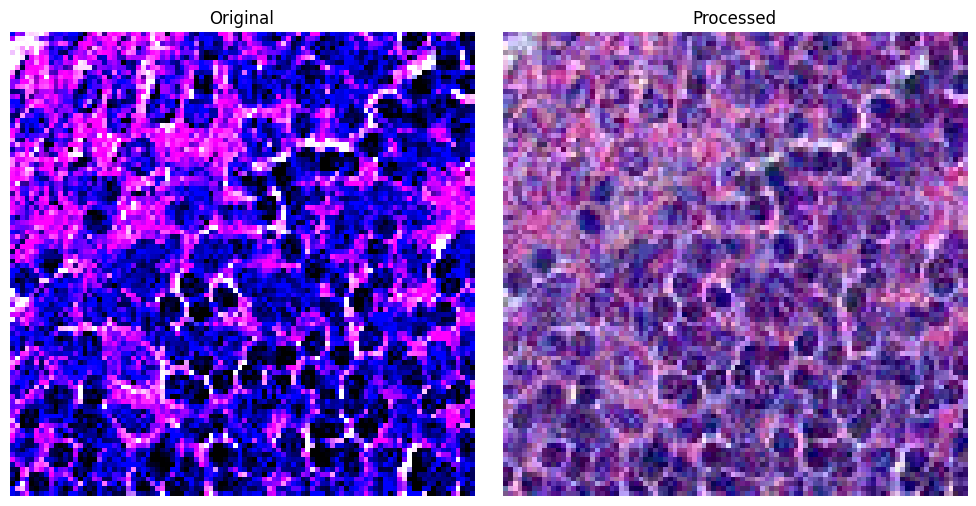

In [ ]:
idx = 5
frame.plot_example(example=adversarial_dataset[idx][0], original=test_dataset[idx][0], denormalize=True)

Run evaluation of the base classifier on the adversarial dataset given by applying the attack over the clean test dataset

In [ ]:
frame._evaluate_dataset(dataset=adversarial_dataset, classifier=frame.base_classifier, name="FGSM_no_defense")

Now, create another classifier which incorporates one or more defense strategies

In [ ]:
defense_classifier = frame._build_classifier(
    defences=[GaussianSmoothing(sigma=1.0)]
)

Run evaluation on the dataset with adversarial examples using the defense classifier rather than the base classifier. The defense classifier has inside some defences

In [ ]:
frame._evaluate_dataset(dataset=adversarial_dataset, classifier=defense_classifier, name="FGSM_gaussian_smoothing")

Now, try the full pipeline. First instantiate a clean framework and then add attacks and defenses

---

# The true pipeline

In [35]:
clean_frame = MyFramework(
    model=model.model,
    test_dataset=test_dataset,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.AdamW(model.model.parameters(), lr=1e-3),
    input_shape=(3, 96, 96),
    num_classes=2,
    channels_first=True,
    clip_values=None,
    batch_size=BATCH_SIZE
)

Add attacks

In [36]:
clean_frame.add_attack("FGSM (eps=0.2)", lambda clf: FastGradientMethod(estimator=clf, eps=0.2))
#clean_frame.add_attack("FGSM (eps=1.0)", lambda clf: FastGradientMethod(estimator=clf, eps=1.0))
#clean_frame.add_attack("PGD (eps=0.3)", lambda clf: ProjectedGradientDescent(estimator=clf, eps=0.3, max_iter=40))
#clean_frame.add_attack("PGD (eps=0.7)", lambda clf: ProjectedGradientDescent(estimator=clf, eps=0.3, max_iter=40))

Add defenses

In [ ]:
settings = {
    "verbose": True
}

clean_frame.add_defense("GaussianSmooth (sigma=0.5)", lambda: GaussianSmoothing(sigma=0.5, **settings))
clean_frame.add_defense("JpegCompression", lambda: JpegCompression(clip_values=(0,1), quality=95, channels_first=True, **settings))
clean_frame.add_defense("LabelSmoothing", lambda: LabelSmoothing(**settings))
clean_frame.add_defense("SpatialSmoothing", lambda: SpatialSmoothingPyTorch(window_size=3, channels_first=True, **settings))
#clean_frame.add_defense("Total Variance Minimization", lambda: TotalVarMin(prob=0.3, max_iter=1, **settings))

The run experiments works in this way:

- creates an empty object to store the metrics
- evaluates the clean test dataset with the base classifier
- loops over the defined attacks (you need to add them, check above)
- for each attack it generates a torch dataset applying the attack on each sample and then evaluates the adversarial crafted test set with base classifier
- then it loops over the defenses and for each it builds the classifier using only that defense and then it evaluates the adversarial crafted test set with the classifier having that defense as countermeasure.


In [38]:
results_df = clean_frame.run_experiments(output_file="results.csv")

Evaluating clean:   0%|          | 0/10 [00:00<?, ?it/s]


Processing attack: FGSM (eps=0.2)


Crafting adversarial (FastGradientMethod):   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating FGSM (eps=0.2)_no_defense:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating FGSM (eps=0.2)_Total Variance Minimization:   0%|          | 0/10 [00:00<?, ?it/s]

...

Variance minimization:   0%|          | 0/512 [00:00<?, ?it/s]

Variance minimization:   0%|          | 0/512 [00:00<?, ?it/s]

Variance minimization:   0%|          | 0/512 [00:00<?, ?it/s]

Variance minimization:   0%|          | 0/512 [00:00<?, ?it/s]

Variance minimization:   0%|          | 0/392 [00:00<?, ?it/s]

In [39]:
results_df.sort_values(by="accuracy", ascending=False)

,attack,defense,accuracy
0,none,none,0.8518
2,FGSM (eps=0.2),Total Variance Minimization,0.2348
1,FGSM (eps=0.2),none,0.2332


Accuray heatmap with defenses and attacks

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


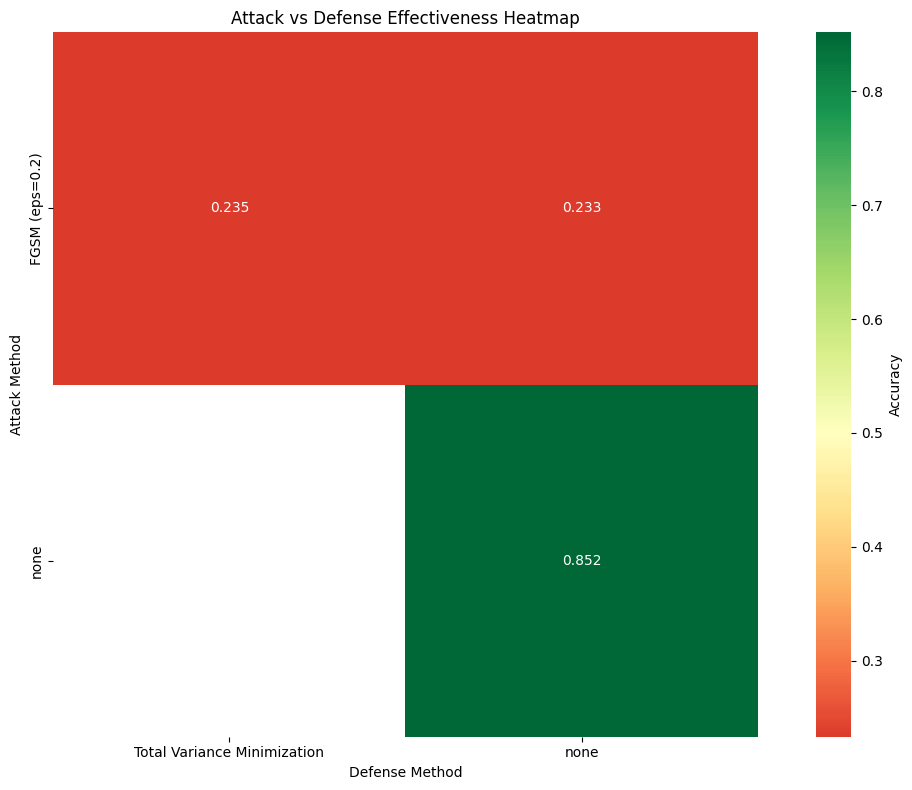

In [40]:
clean_frame.plot_accuracy_heatmap(results_df)

Robustness curves with accuracy, accuracy drop, defense performance radar and stacked performances

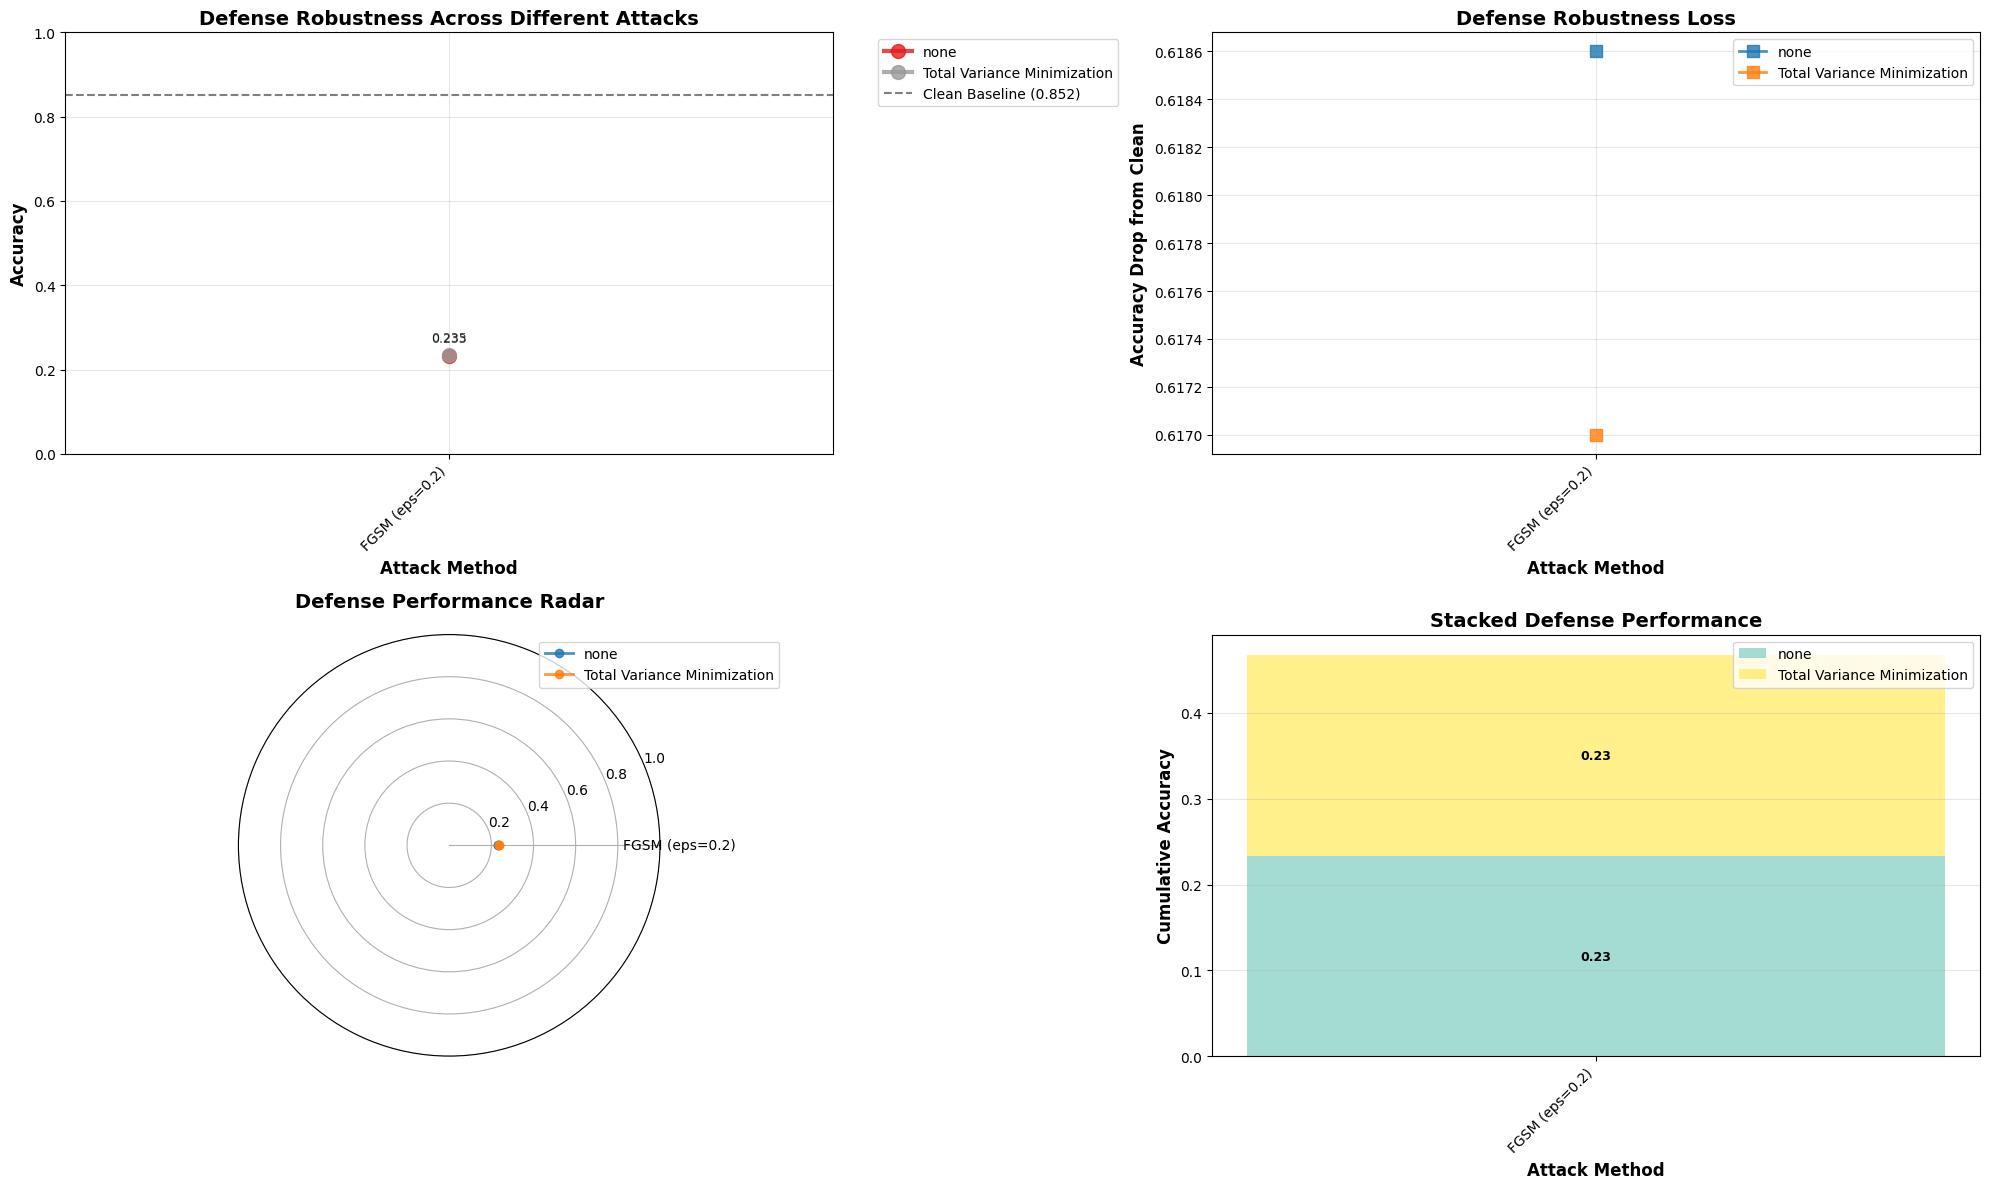


DEFENSE ROBUSTNESS SUMMARY

none:
  Mean Accuracy: 0.233 ± 0.000
  Range: [0.233, 0.233]
  Robustness Score: 0.274
  Most Robust Against: FGSM (eps=0.2) (0.233)
  Least Robust Against: FGSM (eps=0.2) (0.233)

Total Variance Minimization:
  Mean Accuracy: 0.235 ± 0.000
  Range: [0.235, 0.235]
  Robustness Score: 0.276
  Most Robust Against: FGSM (eps=0.2) (0.235)
  Least Robust Against: FGSM (eps=0.2) (0.235)


In [41]:
clean_frame.plot_defense_robustness_curves(results_df)

Which class suffers the most from the attacks based on each attack

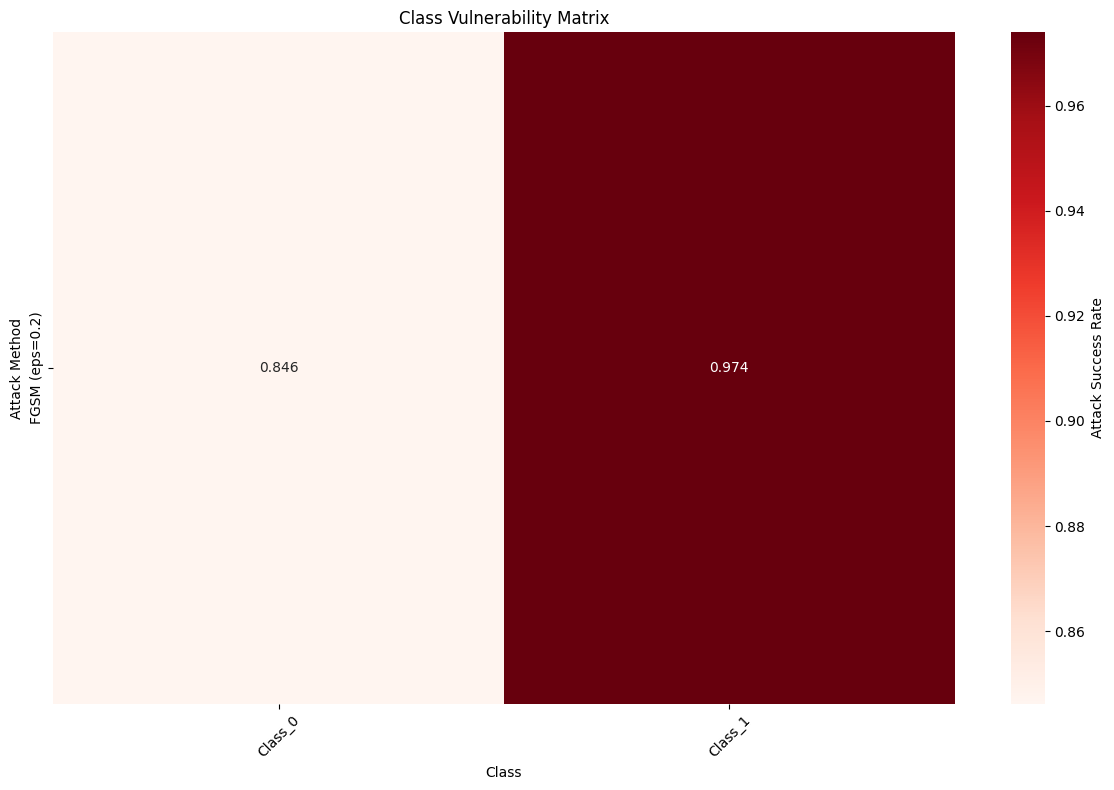

In [42]:
clean_frame.plot_class_vulnerability_matrix(results_df)

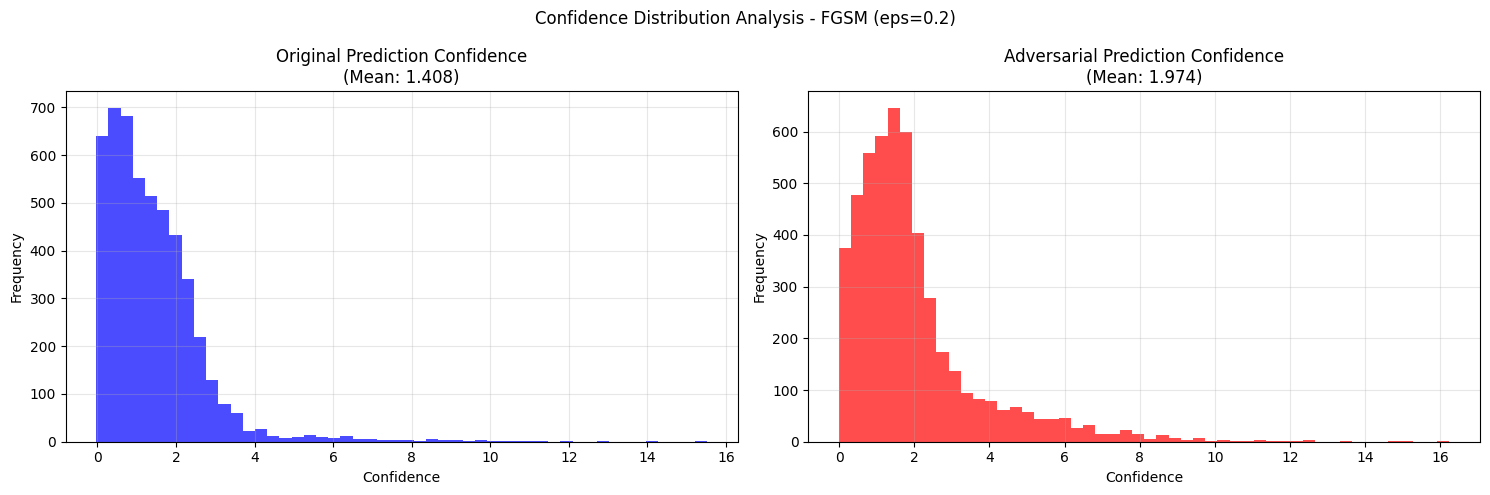

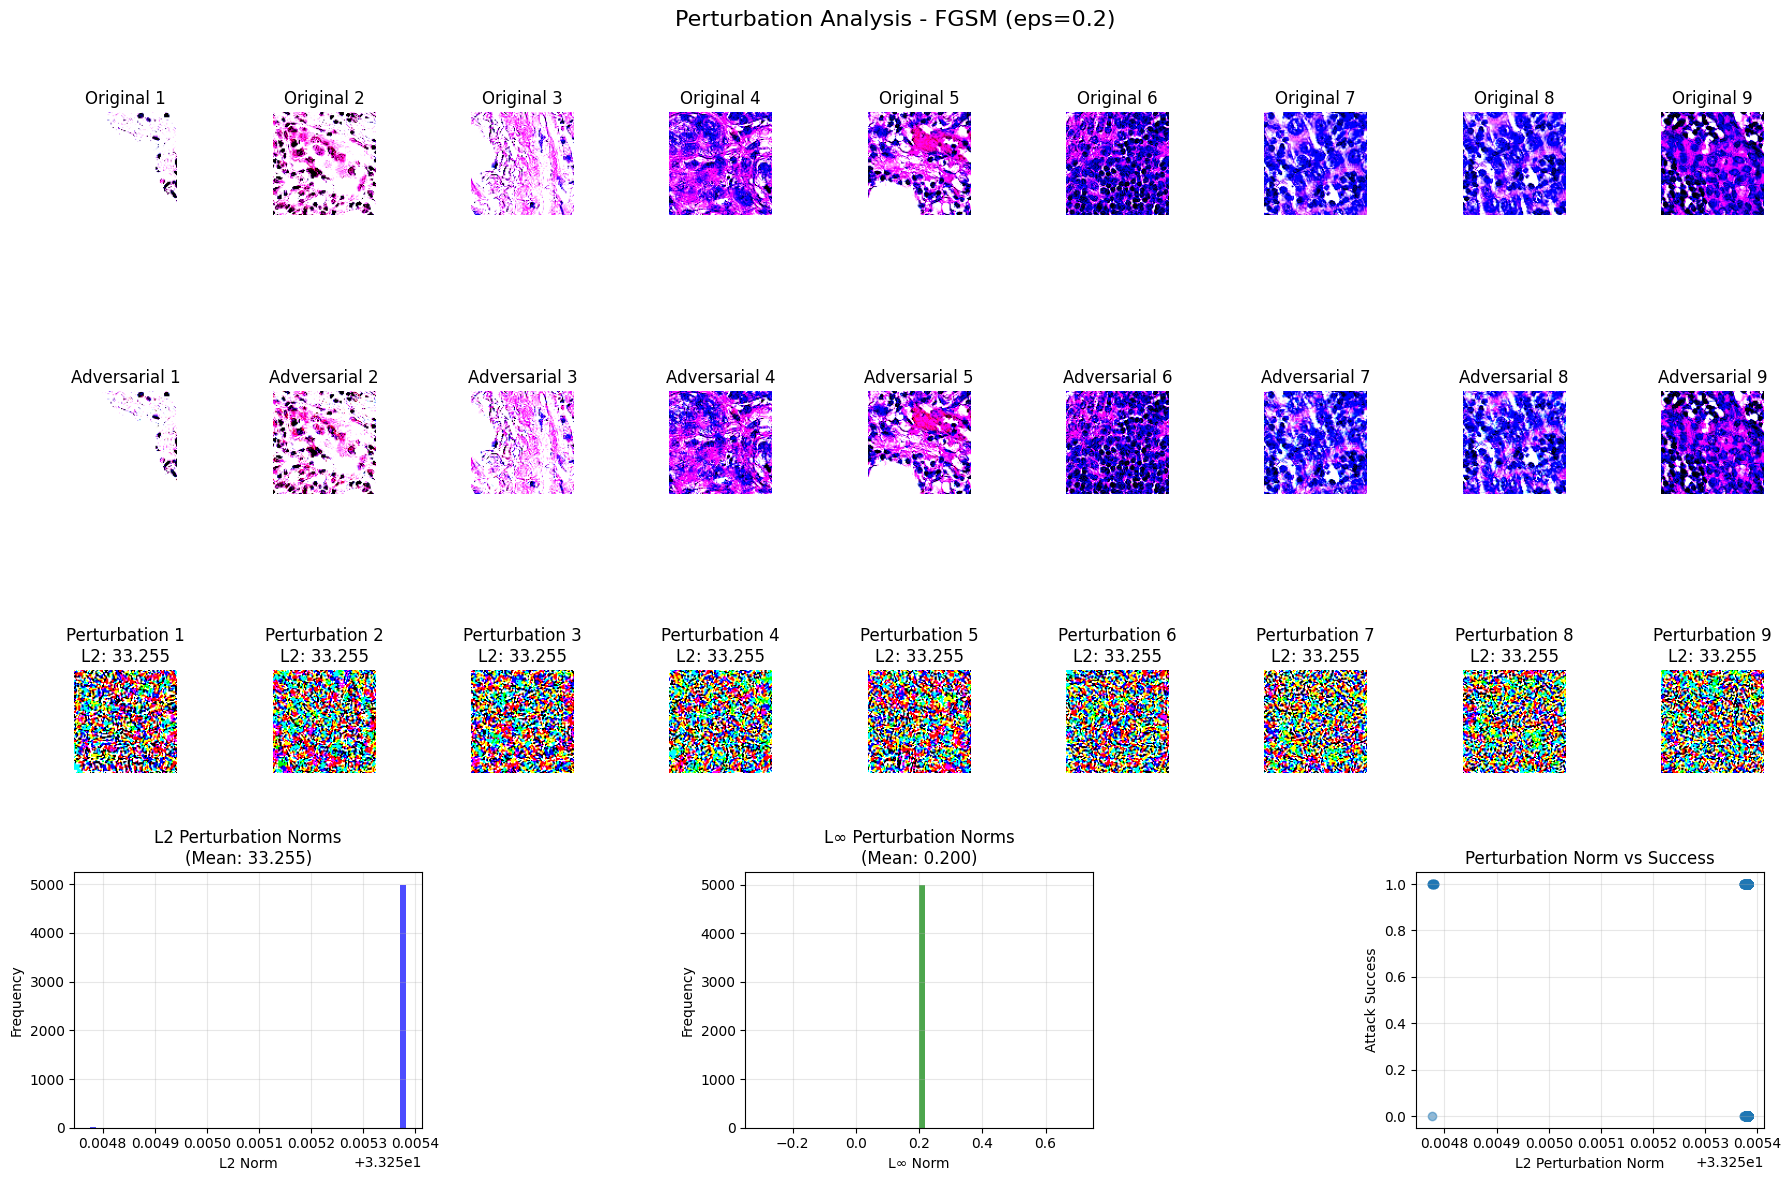

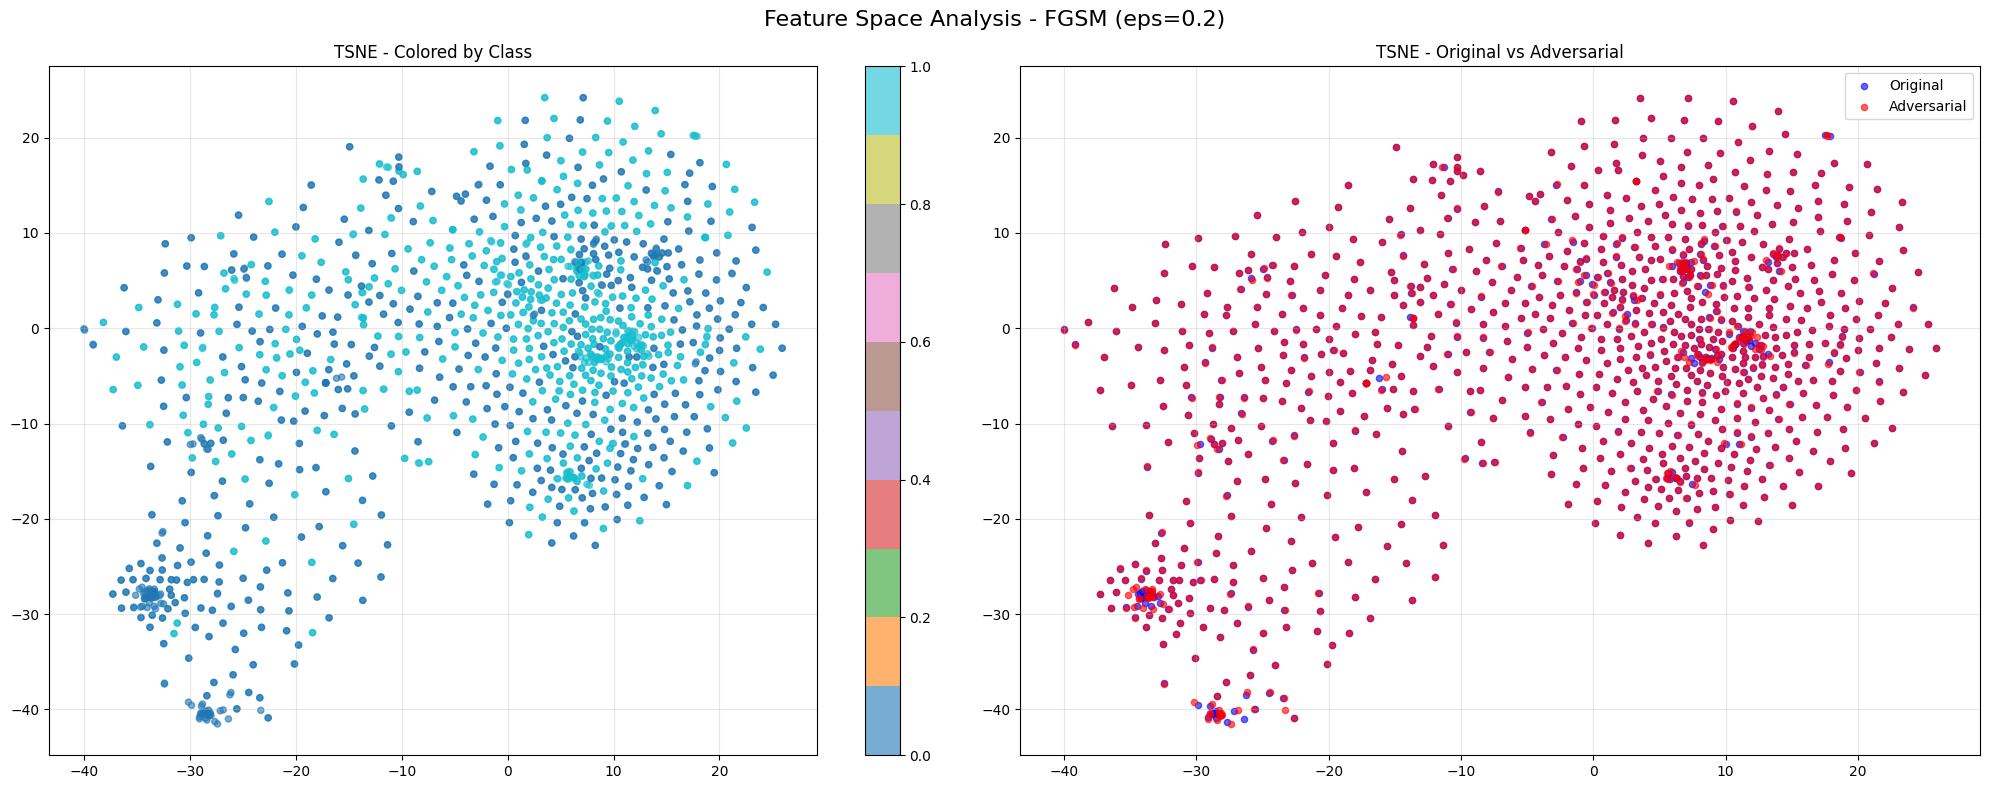

In [43]:
attack_names = [name for name in results_df['attack'].unique() if name != 'none']
for attack_name in attack_names:
    
    # Confidence distributions
    clean_frame.plot_confidence_distributions(attack_name)
    
    # Perturbation analysis
    clean_frame.plot_perturbation_analysis(attack_name)
    
    # Feature space analysis
    if len(clean_frame.detailed_results.get(attack_name, {}).get('original_images', [])) > 0:
        clean_frame.plot_feature_space_analysis(attack_name, method='tsne')